In [1]:
import os
import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt

ROOT_TRAJ = '/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/outputs/lincs-traj/runs/exp/default_v03/output/predict_grid'

DRUG_ID = 'BRD-K12343256'  # Trametinib
CELL_LINE = 'MDAMB231'      # MDA-MB-231
DOSE = 10.0                 # µM — treated condition

GENES = ['ETV1', 'ETS1', 'DUSP6', 'FOXO3']
N_SAMPLES = 10

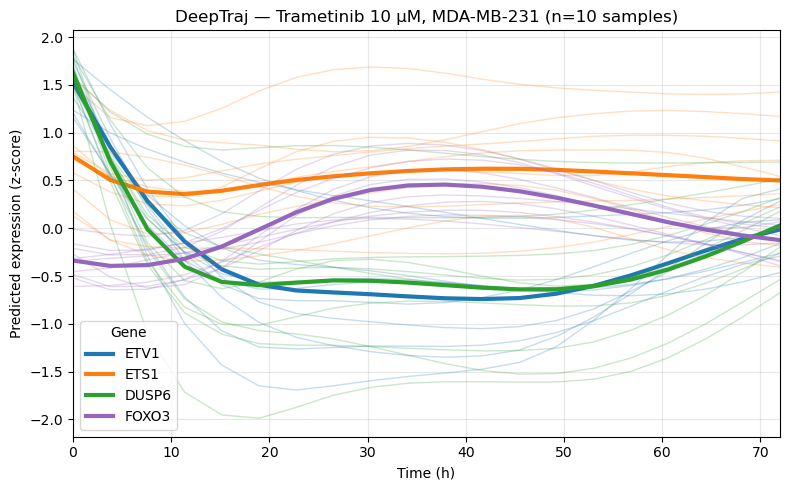

In [2]:
pred_meta = pd.read_csv(os.path.join(ROOT_TRAJ, 'pred_meta.csv'))
gene_names = pd.read_csv(os.path.join(ROOT_TRAJ, 'gene_names.csv'))['gene_names'].astype(str).tolist()
gene_ix = {g: gene_names.index(g) for g in GENES}

cond = pred_meta[
    (pred_meta['pert_id'] == DRUG_ID)
    & (pred_meta['cell_iname'] == CELL_LINE)
    & (pred_meta['dose'] == DOSE)
].iloc[0]

t = np.linspace(cond['time_min'], cond['time_max'], int(cond['n_time_pts']))
file_name = cond['file_name']

# Load trajectories for all 10 DeepTraj samples: (n_samples, n_time, n_genes)
trajs = np.stack([
    torch.load(
        os.path.join(ROOT_TRAJ, f'sample_{si}/obs/{file_name}'),
        weights_only=False,
    ).numpy()
    for si in range(N_SAMPLES)
])

colors = plt.cm.tab10(np.linspace(0, 0.4, len(GENES)))
alpha_sample = 0.25
linewidth_mean = 3

fig, ax = plt.subplots(figsize=(8, 5))

for gi, gene in enumerate(GENES):
    ix = gene_ix[gene]
    gene_trajs = trajs[:, :, ix]  # (n_samples, n_time)

    for si in range(N_SAMPLES):
        ax.plot(t, gene_trajs[si], color=colors[gi], alpha=alpha_sample, linewidth=1)

    ax.plot(
        t,
        gene_trajs.mean(axis=0),
        color=colors[gi],
        linewidth=linewidth_mean,
        label=gene,
    )

ax.set_xlabel('Time (h)')
ax.set_ylabel('Predicted expression (z-score)')
ax.set_title(f'DeepTraj — Trametinib {DOSE:g} µM, MDA-MB-231 (n={N_SAMPLES} samples)')
ax.legend(title='Gene')
ax.set_xlim(t[0], t[-1])
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
ets1_regulon = ['GENE__SQSTM1',
 'GENE__BIRC2',
 'GENE__CSNK2A2',
 'GENE__TRAM2',
 'GENE__COL1A1',
 'GENE__PRKCH',
 'GENE__STK10',
 'GENE__ERBB2',
 'GENE__SPP1',
 'GENE__PARP1',
 'GENE__NR1H2',
 'GENE__SPTLC2',
 'GENE__PTGS2',
 'GENE__MMP2',
 'GENE__ILK',
 'GENE__TP53',
 'GENE__HMOX1',
 'GENE__FOSL1',
 'GENE__CD44',
 'GENE__CDKN1A',
 'GENE__CCL2',
 'GENE__NOS3',
 'GENE__BCL2',
 'GENE__FAS',
 'GENE__MMP1',
 'GENE__BMP4',
 'GENE__TBXA2R',
 'GENE__DNMT1',
 'GENE__CDKN1B',
 'GENE__SERPINE1',
 'GENE__CXCR4',
 'GENE__MYC',
 'GENE__TGFBR2',
 'GENE__DUSP6',
 'GENE__CCND3',
 'GENE__EGR1',
 'GENE__CDKN2A',
 'GENE__TERT',
 'GENE__BAX',
 'GENE__FYN',
 'GENE__STAT1',
 'GENE__GATA2',
 'GENE__RAI14',
 'GENE__PDGFA',
 'GENE__BID',
 'GENE__CCND1',
 'GENE__ADAM10',
 'GENE__DAXX',
 'GENE__TFAP2A',
 'GENE__FOS',
 'GENE__CCNA2',
 'GENE__SPRED2']

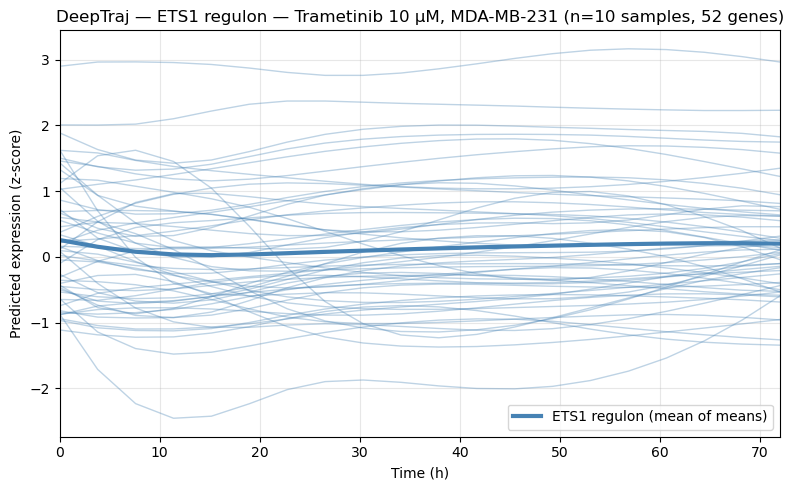

In [8]:
regulon_genes = [g.replace('GENE__', '') for g in ets1_regulon]
regulon_ix = [gene_names.index(g) for g in regulon_genes]

color = 'steelblue'
alpha_gene_mean = 0.35
linewidth_regulon_mean = 3

fig, ax = plt.subplots(figsize=(8, 5))

gene_means = []
for ix in regulon_ix:
    gene_mean = trajs[:, :, ix].mean(axis=0)  # mean across samples
    gene_means.append(gene_mean)
    ax.plot(t, gene_mean, color=color, alpha=alpha_gene_mean, linewidth=1)

regulon_mean = np.stack(gene_means).mean(axis=0)
ax.plot(t, regulon_mean, color=color, linewidth=linewidth_regulon_mean, label='ETS1 regulon (mean of means)')

ax.set_xlabel('Time (h)')
ax.set_ylabel('Predicted expression (z-score)')
ax.set_title(f'DeepTraj — ETS1 regulon — Trametinib {DOSE:g} µM, MDA-MB-231 (n={N_SAMPLES} samples, {len(regulon_genes)} genes)')
ax.legend()
ax.set_xlim(t[0], t[-1])
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

ETS1 regulon genes with negative AUC (24 / 52):
['DUSP6', 'FOSL1', 'CCNA2', 'DNMT1', 'CXCR4', 'MYC', 'SPRED2', 'MMP1', 'CD44', 'CCND1', 'PARP1', 'BCL2', 'EGR1', 'FAS', 'CCND3', 'TGFBR2', 'SPTLC2', 'STK10', 'PRKCH', 'RAI14', 'BAX', 'TP53', 'ILK', 'SERPINE1']


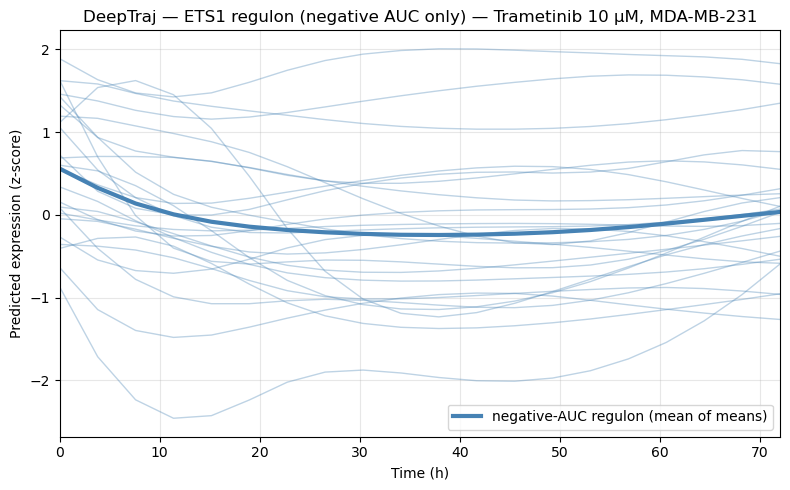

In [9]:
regulon_genes = [g.replace('GENE__', '') for g in ets1_regulon]

auc_rows = []
for gene in regulon_genes:
    ix = gene_names.index(gene)
    gene_mean = trajs[:, :, ix].mean(axis=0)
    auc = np.trapz(gene_mean - gene_mean[0], t)
    auc_rows.append({'gene': gene, 'auc': auc})

auc_df = pd.DataFrame(auc_rows).sort_values('auc')
neg_auc_genes = auc_df.loc[auc_df['auc'] < 0, 'gene'].tolist()

print(f'ETS1 regulon genes with negative AUC ({len(neg_auc_genes)} / {len(regulon_genes)}):')
print(neg_auc_genes)

color = 'steelblue'
alpha_gene_mean = 0.35
linewidth_regulon_mean = 3

fig, ax = plt.subplots(figsize=(8, 5))

gene_means = []
for gene in neg_auc_genes:
    ix = gene_names.index(gene)
    gene_mean = trajs[:, :, ix].mean(axis=0)
    gene_means.append(gene_mean)
    ax.plot(t, gene_mean, color=color, alpha=alpha_gene_mean, linewidth=1)

regulon_mean = np.stack(gene_means).mean(axis=0)
ax.plot(
    t,
    regulon_mean,
    color=color,
    linewidth=linewidth_regulon_mean,
    label='negative-AUC regulon (mean of means)',
)

ax.set_xlabel('Time (h)')
ax.set_ylabel('Predicted expression (z-score)')
ax.set_title(
    f'DeepTraj — ETS1 regulon (negative AUC only) — Trametinib {DOSE:g} µM, MDA-MB-231'
)
ax.legend()
ax.set_xlim(t[0], t[-1])
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()